<h1><center>Laboratorio 4: EDA en Pandas 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Agustin Eduardo Gonzalez Hidalgo
- Nombre de alumno 2: Vicente Ignacio Thiele Muñoz

### **Link de repositorio de GitHub:** `https://github.com/elvixooo/Laboratorios-MDS7202/tree/main`


## Reglas:

- **Grupos de 2 personas**
- Asistencia **obligatoria** a instrucciones del lab (viernes 16.15). Luego, pueden quedarse trabajando en las salas o irse.
- **No se revisarán entregas de personas ausentes**. 
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias. 
- Pueden usar cualquer matrial del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Aplicar los paradigmas y buenas prácticas de programación vistas hasta este momento.
- Utilizar las funciones de la librería `pandas` para realizar análisis exploratorio de datos
- Aplicar principios de visualización de datos vistos en clases para mostrar patrones en los datos


El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas de `pandas`.

## Descripción del laboratorio.

### Importamos librerias utiles 😸

In [1]:
# Libreria Core del lab.

# Libreria para plotear
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import Markdown, display
from scipy import stats

# Segmentación de Clientes en Tienda de Retail 🛍️

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

## 1.1 Cargar dataset [0.5 puntos]

Mr. Lepin Mora quien es el gerente de una cotizada tienda de retail en Europa, les solicita si pueden analizar los datos de algunas de sus tiendas.

Para esto, el área de ventas les entrega el 2 archivos: `online_retail_II.pickle` y `online_retail_I.pickle`.
- Cargue ambas fuentes y asegúrese que las columnas son del tipo correcto como en el ejemplo de df_retail_1 visualizando los datos para determinar el tipo. Para fechas, puede usar `'datetime64[ns]'`
- Combine los dataframes en uno solo. ¿Qué función debe utilizar en este caso?
- Señale las columnas que componen el dataset combinado, el tipo de variable presente en cada columna y comente que representa cada una de estas.

**Respuesta:**

In [2]:
df_retail_1 = pd.read_pickle("online_retail_I.pickle")
df_retail_1 = df_retail_1.astype(
    {
        "Invoice": "category",
        "StockCode": "category",
        "Description": str,
        "Customer ID": "category",
        "Quantity": int,
        "Price": float,
        "Country": "category",
    }
)
df_retail_1.head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom


In [3]:
df_retail_2 = pd.read_pickle("online_retail_II.pickle")

df_retail_2 = df_retail_2.astype(
    {
        "Invoice": "category",
        "InvoiceDate": "datetime64[ns]",
    }
)

df_retail_2.head()

,Invoice,InvoiceDate
0,489434,2009-12-01 07:45:00
1,489435,2009-12-01 07:46:00
2,489436,2009-12-01 09:06:00
3,489437,2009-12-01 09:08:00
4,489438,2009-12-01 09:24:00


Juntamos los dataframes con merge en vez de concat para que estos se combinen en base a un identificador común. En este caso Invoice.

In [4]:
df_retail = pd.merge(df_retail_1, df_retail_2, on="Invoice", how="outer")

df_retail.head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom,2009-12-01 07:45:00


El dataset combinado esta compuesto de 8 columnas. Que son las siguientes:

- Invoice: Es de tipo category, y representa el id de la transacción.
- StockCode: Es de tipo category, y representa el código del producto.
- Description: Es de tipo str, y describe al producto con su nombre.
- Quantity: Es de tipo int, y representa a la cantidad de producto por transacción.
- Price: Es de tipo float, y representa al precio por unidad de producto.
- Costumer ID: Es de tipo category, y representa al id del comprador.
- Country: Es de tipo category, y representa el país desde donde se hizo la compra.
- InvoiceDate: Es de tipo datetime64[ns], y representa la fecha en la que se genero la transacción.

## 1.2 Análisis Explotatorio de los Datos [0.5 puntos] 

En base a la primera visualización del dataset, *Don Mora* le solicita que realicen un análisis exploratorio de los datos, para esto les deberán realizar un análisis univariado y multivariado. De la revisión, ustedes deben explicar potenciales anomalías visualizadas y señalar si existe la necesidad de realizar una limpieza de datos.

Explique a que nos referimos con análisis univariable, multivariable y de datos faltantes. ¿Qué beneficios nos otorga estudiar estos datos?. Sea conciso con su respuesta y no escriba mas de 5 líneas para su respuesta.

**Respuesta a la Pregunta:**

- El análisis univariable estudia cada variable del modelo por separado, permitiendo entender la distribución, detectar patrones, outliers, etc.
- El análisis multivarible estudia la relación entre más de dos variables de manera simultanea. Teniendo así un análisis más global del dataset.
- El análisis de datos faltantes nos permite hacer una inspección/verificación de los datos que pueden no estar presentes en el dataset y causar anomalias y afectar el análisis posterior.

Estudiar estos datos nos ayuda a entender el dataset a profundidad, como se comportan las variables por si solas y entre ellas, ver que datos pueden faltan y tratarlos como es debido para que después no afecte el desarrollo del proyecto en el que se enmarca el análisis.

### 1.2.1 Análisis Univariado [1.5 Puntos]

A continuación, se le presentan dos funciones para analizar los datos que componen un dataframe. La primera de estas es la función ``profile_serie()`` la cual recibe una serie y le entrega un análisis detallado de los datos que conforman dicha serie. 

Ejecute la funcion ``profile_serie()`` sobre cada serie para realizar un análisis univariado de estas. A continuación, comente acerca de el comportamiento de cada variable según las estadísticas descriptivas y los gráficos generados.

In [5]:
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype, is_timedelta64_dtype


def profile_serie(serie_in, n_samples=1000, random_state=42):
    serie = serie_in.copy()

    profile = pd.Series(dtype="object")
    profile["Type"] = serie.dtype
    profile = pd.concat([profile, serie.describe()])

    # profile = pd.Series([])

    if is_numeric_dtype(serie):
        profile["Negative"] = (serie < 0).sum()
        profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Zeros"] = (serie == 0).sum()
        profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Kurt"] = serie.kurt()
        profile["Skew"] = serie.skew()

    profile[" "] = " "  # espacio

    profile["Missing cells"] = serie.isnull().sum()
    profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
    profile["Duplicate rows"] = serie.duplicated(False).sum()
    profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
    profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

    # profile = pd.concat([profile, description])

    profile = profile.rename(
        index={
            "count": "Number of observations",
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "max": "Max",
            "unique": "Unique",
            "top": "Top",
            "freq": "Freq",
        }
    )
    no_outliers_fig = None

    if is_numeric_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name} - With Outliers")

        no_outliers = sampled_serie.loc[(np.abs(stats.zscore(sampled_serie)) < 3)]
        # zscore = https://es.wikipedia.org/wiki/Unidad_tipificada

        no_outliers_fig = px.histogram(no_outliers, marginal="box", title=f"{serie.name} - Without Outliers")

    elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")

    else:
        count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
        fig = px.bar(
            x=count[serie.name].astype(str),
            y=count["Count"],
            title=f"100 Most common categories of {serie.name}",
        )
    display(Markdown(f"## {serie.name} Profile"))
    display(profile)
    fig.show()

    if no_outliers_fig:
        no_outliers_fig.show()

    # return fig, profile

In [6]:
profile_serie(df_retail["Price"])

## Price Profile

Type                            float64
Number of observations         525461.0
Mean                           4.688834
Std                          146.126914
Min                           -53594.36
25%                                1.25
50%                                 2.1
75%                                4.21
Max                            25111.09
Negative                              3
Negative (%)                      0.0 %
Zeros                              3687
Zeros (%)                         0.7 %
Kurt                       64868.344873
Skew                        -140.768446
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   524485
Duplicate rows (%)              99.81 %
Total size in memory      4203820 bytes
dtype: object

    Análisis de la primera serie (Price)

    Podemos notar que en las estadisticas descriptivas el valor minimo es negativo (-53594.36), lo cual es extraño considerando que son precios de productos, pero estos valores son pocos, solo son 3. Otra anomalía, es que existen valores iguales a 0 para el precio, son 3687 registros, que representan un 0.7% de los datos totales. Estos valores deben ser tratados.

    Otra cosa que podemos notar es el valor de la desviación estandar (146.126914), lo cual nos da a entender que los datos estan muy dispersos, que también es apreciable en el gráfico, en donde notamos una gran concentración alrededor de la media, que es igual a 4.688834, pero se tienen valores que se alejan mucho de este valor, pero son mucho menos en cantidad, esto nos permite concluir que las ventas se concentran sobre todo en prodcutos que tienen un precio económico y no aquellos que son de mayor precio, con los percentiles nos damos cuenta que hasta el 75% todavía se tiene un valor cercano a la media y después estos se alejan más.

In [7]:
profile_serie(df_retail["Customer ID"])

## Customer ID Profile

Type                           category
Number of observations         417534.0
Unique                           4383.0
Top                             14911.0
Freq                             5710.0
                                       
Missing cells                    107927
Missing cells (%)               20.54 %
Duplicate rows                   525327
Duplicate rows (%)              99.97 %
Total size in memory      1086118 bytes
dtype: object

    Análisis de la segunda serie (Customer ID)

    En las estadisticas descriptivas vemos que existe una gran cantidad de valores faltantes, cercano al 21% de los datos totales, esto podría llevar a errores o sesgos en posteriores análisis, por lo que debe ser tratado. Lo otro que vemos en el gráfico es que este solo muestra el top 100 de los registros, y ya notamos que existe una concentración de los datos en unos pocos clientes, que son los que compran más, que representan cerca del 10% de los top 100 customers, y el resto debe comprar una sola vez y pocos productos, y duplicate rows nos da a entender que los clientes suelen comprar más de un solo producto, ya que la cantidad de duplicados es alta, alcanzando valores de 99,97%.

In [8]:
profile_serie(df_retail["Country"])

## Country Profile

Type                            category
Number of observations            525461
Unique                                40
Top                       United Kingdom
Freq                              485852
                                        
Missing cells                          0
Missing cells (%)                  0.0 %
Duplicate rows                    525461
Duplicate rows (%)               100.0 %
Total size in memory        526985 bytes
dtype: object

    Análisis de la tercera serie (Country)

    De las estadisticas descriptivas y el gráfico notamos que la mayoria de los registros se concentran en el valor United Kingdom, a pesar de que se tienen compras en 40 paises distintos, esto genera un desbalance para la serie Country, lo cual dificulta un análisis en profundidad para esta serie. Y no existen valores faltantes.

In [9]:
profile_serie(df_retail["InvoiceDate"])

## InvoiceDate Profile

Type                                     datetime64[ns]
Number of observations                           525461
Mean                      2010-06-28 11:37:36.619958272
Min                                 2009-12-01 07:45:00
25%                                 2010-03-21 12:20:00
50%                                 2010-07-06 09:51:00
75%                                 2010-10-15 12:45:00
Max                                 2010-12-09 20:01:00
                                                       
Missing cells                                         0
Missing cells (%)                                 0.0 %
Duplicate rows                                   520408
Duplicate rows (%)                              99.04 %
Total size in memory                      4203820 bytes
dtype: object

    Análisis de la cuarta serie (InvoiceDate)

    Primero notamos que los registros de compras corresponden a transacciones realizadas a finales de 2009 y todo 2010, donde no existen valores faltantes.

    Lo que podemos ver a través del gráfico es que este sigue una distribución uniforme, pero alcanza valores de mayor frecuencia a finales del año, esto lo relacionamos con las compras de las festivades como halloween, navidad, etc. Y también se tiene que la media esta ubicada a mediados de años (Julio-Agosto), lo cual tiene un sentido temporal.

In [10]:
profile_serie(df_retail["Invoice"])

## Invoice Profile

Type                           category
Number of observations           525461
Unique                            28816
Top                              537434
Freq                                675
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   517456
Duplicate rows (%)              98.48 %
Total size in memory      2338390 bytes
dtype: object

    Análisis de la quinta serie (Invoice)

    De la estadistica descriptiva notamos que hay 0 valores nulos, y que hay un gran porcentaje de duplicados, con respecto a otros gráficos podemos concluir que al ser Invoice las id de las transacciones, se muestra un comportamiento más distribuido de las frecuencias por transacción, en donde se suelen comprar muchos productos por transacción, pero no existe una diferencia abismal entre la transacción en la que se hizo más compra y las que le siguen que van disminuyendo de forma continua.

In [11]:
profile_serie(df_retail["StockCode"])

## StockCode Profile

Type                           category
Number of observations           525461
Unique                             4632
Top                              85123A
Freq                               3516
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525026
Duplicate rows (%)              99.92 %
Total size in memory      1220246 bytes
dtype: object

    Análisis de la sexta serie (StockCode)

    Nuevamente podemos notar que con la estadistica descriptiva no se tienen valores nulos y hay gran cantidad de duplicados. Del gráfico notamos que claramente hay un producto que se compra mucho más que los demás, y que después disminuye la cantidad de compras por producto, y esta frecuencia se "estabiliza" a un valor muy por debajo del más frecuente.

In [12]:
profile_serie(df_retail["Description"])

## Description Profile

Type                                                     str
Number of observations                                522533
Unique                                                  4681
Top                       WHITE HANGING HEART T-LIGHT HOLDER
Freq                                                    3549
                                                            
Missing cells                                           2928
Missing cells (%)                                     0.56 %
Duplicate rows                                        525198
Duplicate rows (%)                                   99.95 %
Total size in memory                           4203820 bytes
dtype: object

    Análisis de la septima serie (Description)

    Esta serie si tiene valores nulos o missing, y nuevamente tiene una gran cantidad de duplicados. Al igual que StockCode se tiene un comportamiento similar en el gráfico en donde el producto más comprado es muy superior en frecuencia con respecto a los demás y después del top 3 ya se puede ir notando una estabilización del gráfico.

In [13]:
profile_serie(df_retail["Quantity"])

## Quantity Profile

Type                              int64
Number of observations         525461.0
Mean                          10.337667
Std                           107.42411
Min                             -9600.0
25%                                 1.0
50%                                 3.0
75%                                10.0
Max                             19152.0
Negative                          12326
Negative (%)                     2.35 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                        6277.666908
Skew                          36.044617
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525122
Duplicate rows (%)              99.94 %
Total size in memory      4203820 bytes
dtype: object

    Análisis de la ocatava serie (Quantity)

    A través de la estadistica descriptiva notamos que hay valores minimos que no se corresponden con la serie observada, ya que al ser la cantidad de productos no se deberian tener valores negativos, y acá tenemos un valor minimo igual -9600.00, y los valores negativos corresponden al 2.35% de los datos totales, esto debe ser tratado. No hay valores faltantes, y se puede notar una dispersión en los datos, lo cual se ve reflejado en el valor de la desviación estandar (107.42411) y el promedio (10.337667). Y en cuanto a los cuartiles notamos que el 25% es 1.0, el 50% es 3.0 y el 75% es 10, mientras que el valor maximo corresponde a 19152.0, lo cual muestra una gran diferencia entre los cuartiles demostrando la presencia de outliers por estos valores muy alejados, tanto positiva, como negativamente.

### 1.2.2 Análisis Multivariado y Datos Faltantes [1 ptos]

En segundo lugar encontrará la función ``profile_df()`` que recibe un dataframe como entrada y realiza un análisis bivariado de todas las variables numéricas que conforman el dataframe, un analisis de la correlación de Pearson entre las variables numericas del dataframe y la matriz de datos faltantes.

Utilice esta función en el dataframe. Comente sobre los patrones que observa. Luego responda:
- Existen correlaciones relevantes observadas?
- Qué aspectos revelan estos gráficos acerca de la limpieza de los datos?

In [14]:
def profile_df(dataframe_in):
    df = dataframe_in.copy()

    list_type = []
    for col in list(df.columns):
        if is_numeric_dtype(df[col]) or is_datetime64_any_dtype(df[col]) or is_timedelta64_dtype(df[col]):
            list_type.append(col)

    display(Markdown("## Bivariant Analysis:"))
    for i in range(len(list_type)):
        for j in range(i + 1, len(list_type)):
            plt.scatter(df[list_type[i]], df[list_type[j]])
            plt.xlabel(list_type[i])
            plt.ylabel(list_type[j])
            plt.title(f"{list_type[i]} v/s {list_type[j]}")
            plt.show()

    display(Markdown("## Correlation:"))
    fig_corr = px.imshow(df[list_type].corr())
    fig_corr.show()

    display(Markdown("## Missing Matrix:"))
    fig, ax = plt.subplots(figsize=[15, 10])
    msno.matrix(df, ax=ax, sparkline=False)

## Bivariant Analysis:

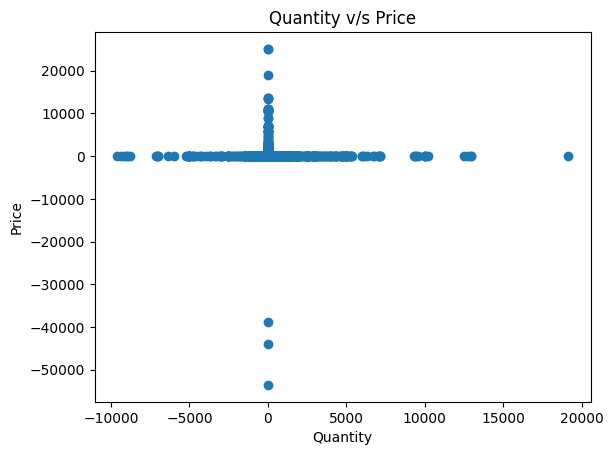

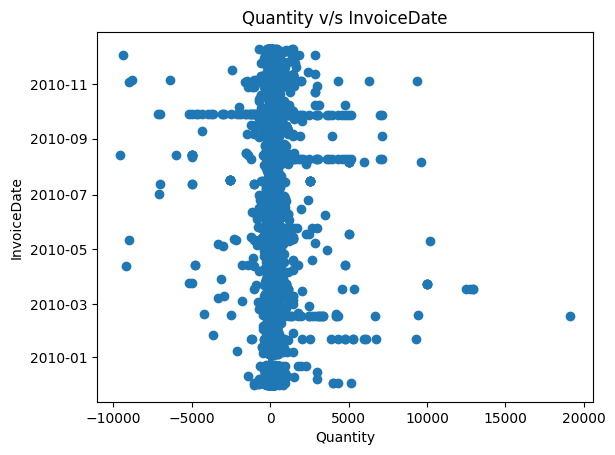

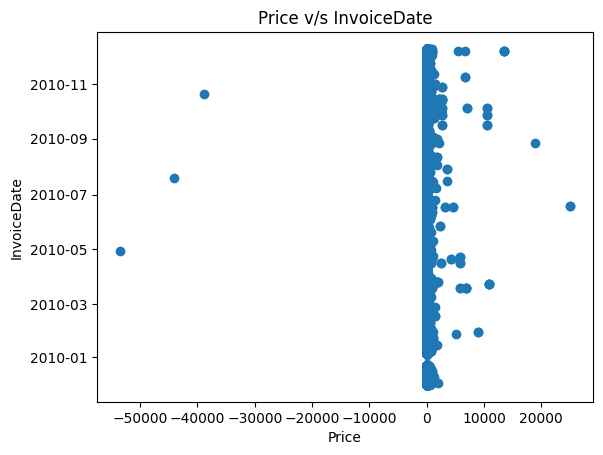

## Correlation:

## Missing Matrix:

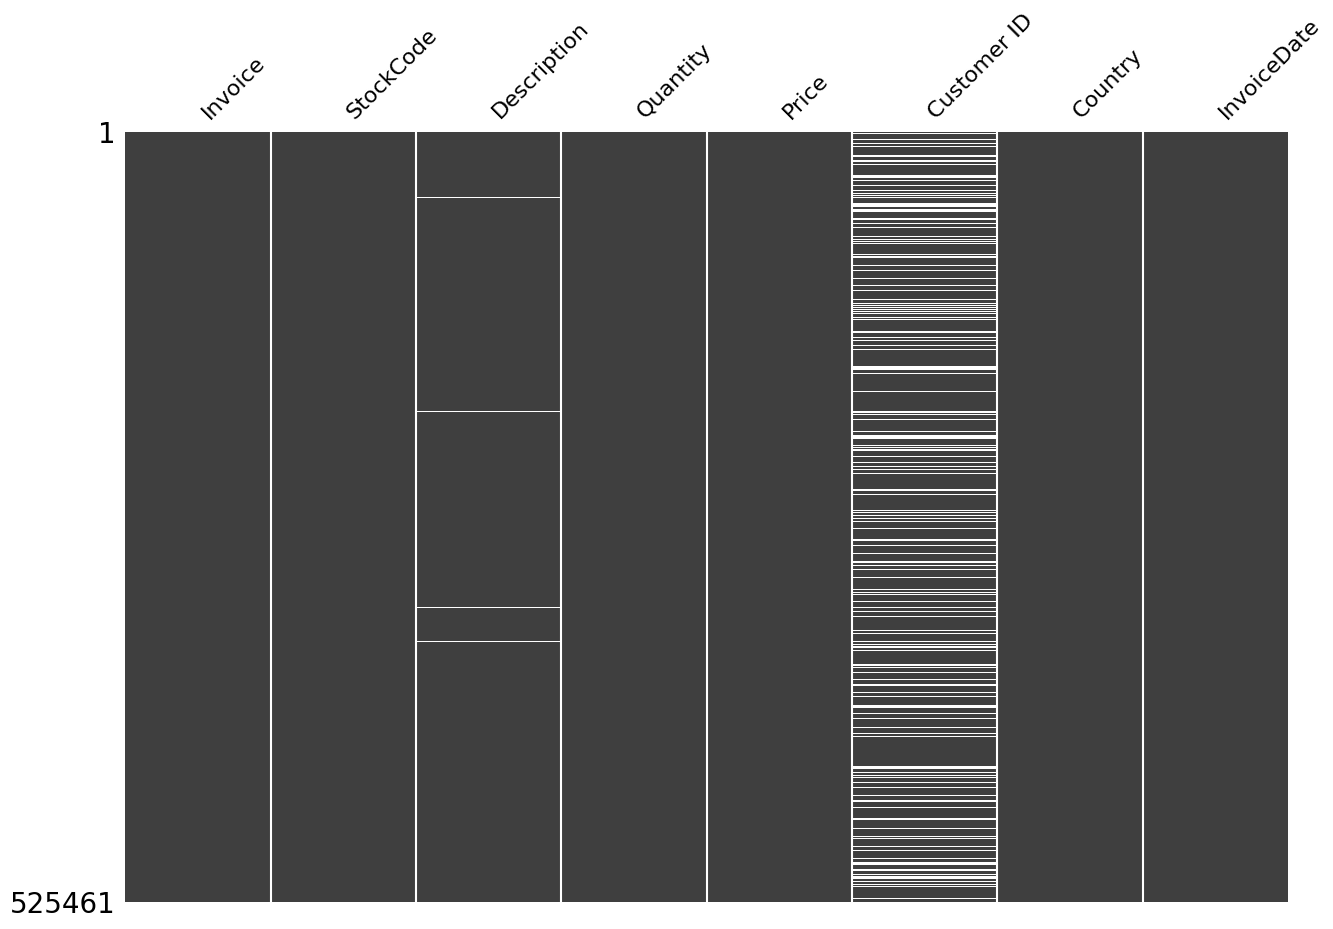

In [15]:
profile_df(df_retail)

Tomando en cuenta los primeros 3 gráficos y la matriz de correlación podemos notar que existe correlación cercana a 0, pero que alcanza valores negativos entre las variables Quantity, Price y InvoiceDate.

Y con respecto a la limpieza de los datos tenemos que para Quantity y Price los datos no se han limpiado, ya que existe presencia de valores negativos para ambas variables y con respecto a la missing matrix podemos notar que tampoco hay tratamiento para los valores nulos de Description y Customer ID.

### 1.2.3 Limpieza de Datos [1 pto]

Como pudo ver en las secciones anteriores, los datos presentan valores erroneos, es por esto que se le solicita que realice una función que permita limpiar el dataset. Realice esta función en base observaciones propias y considere como **imposible tener cantidades negativas** en las ventas. Investigue sobre métodos para eliminar outliers usando pandas

Una vez realizada la función, realice nuevamente el análisis exploratorio y comente las principales diferencias.

**Respuesta:**

In [16]:
def clean_dataset(df):
    df_clean = df.copy()
    df_clean = df_clean.dropna()
    df_clean = df_clean[df_clean["Quantity"] > 0]
    df_clean = df_clean[df_clean["Price"] > 0]
    for col in ["Quantity", "Price"]:
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        df_clean = df_clean[df_clean[col].between(lower, upper)]
    return df_clean


df_clean = clean_dataset(df_retail)

In [17]:
profile_serie(df_clean["Price"])

## Price Profile

Type                            float64
Number of observations         348613.0
Mean                           2.355532
Std                            1.661376
Min                               0.001
25%                                1.25
50%                                1.95
75%                                2.95
Max                                 7.5
Negative                              0
Negative (%)                      0.0 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                           0.739157
Skew                           1.162888
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   348585
Duplicate rows (%)              99.99 %
Total size in memory      5577808 bytes
dtype: object

In [18]:
profile_serie(df_clean["Customer ID"])

## Customer ID Profile

Type                           category
Number of observations         348613.0
Unique                           4140.0
Top                             17841.0
Freq                             4683.0
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   348547
Duplicate rows (%)              99.98 %
Total size in memory      3521194 bytes
dtype: object

In [19]:
profile_serie(df_clean["Country"])

## Country Profile

Type                            category
Number of observations            348613
Unique                                37
Top                       United Kingdom
Freq                              320314
                                        
Missing cells                          0
Missing cells (%)                  0.0 %
Duplicate rows                    348613
Duplicate rows (%)               100.0 %
Total size in memory       3138909 bytes
dtype: object

In [20]:
profile_serie(df_clean["InvoiceDate"])

## InvoiceDate Profile

Type                                     datetime64[ns]
Number of observations                           348613
Mean                      2010-07-01 07:01:29.108380672
Min                                 2009-12-01 07:45:00
25%                                 2010-03-25 13:55:00
50%                                 2010-07-11 12:00:00
75%                                 2010-10-15 12:11:00
Max                                 2010-12-09 20:01:00
                                                       
Missing cells                                         0
Missing cells (%)                                 0.0 %
Duplicate rows                                   347581
Duplicate rows (%)                               99.7 %
Total size in memory                      5577808 bytes
dtype: object

In [21]:
profile_serie(df_clean["Invoice"])

## Invoice Profile

Type                           category
Number of observations           348613
Unique                            17216
Top                              531382
Freq                                239
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   347438
Duplicate rows (%)              99.66 %
Total size in memory      4773466 bytes
dtype: object

In [22]:
profile_serie(df_clean["StockCode"])

## StockCode Profile

Type                           category
Number of observations           348613
Unique                             3644
Top                              85123A
Freq                               2500
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   348447
Duplicate rows (%)              99.95 %
Total size in memory      3655322 bytes
dtype: object

In [23]:
profile_serie(df_clean["Description"])

## Description Profile

Type                                                     str
Number of observations                                348613
Unique                                                  4019
Top                       WHITE HANGING HEART T-LIGHT HOLDER
Freq                                                    2500
                                                            
Missing cells                                              0
Missing cells (%)                                      0.0 %
Duplicate rows                                        348401
Duplicate rows (%)                                   99.94 %
Total size in memory                           5577808 bytes
dtype: object

In [24]:
profile_serie(df_clean["Quantity"])

## Quantity Profile

Type                              int64
Number of observations         348613.0
Mean                            7.12577
Std                            6.618329
Min                                 1.0
25%                                 2.0
50%                                 5.0
75%                                12.0
Max                                27.0
Negative                              0
Negative (%)                      0.0 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                           0.942399
Skew                           1.293853
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   348613
Duplicate rows (%)              100.0 %
Total size in memory      5577808 bytes
dtype: object

## Bivariant Analysis:

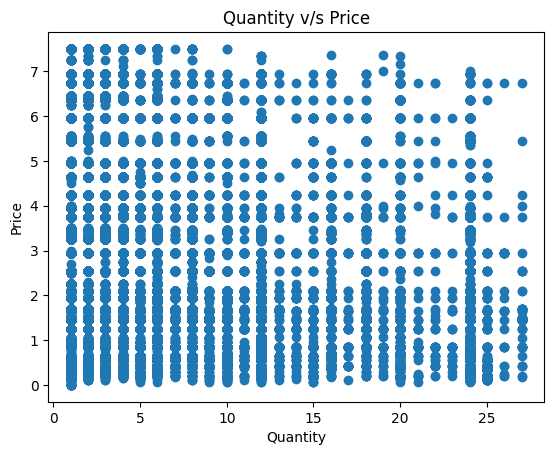

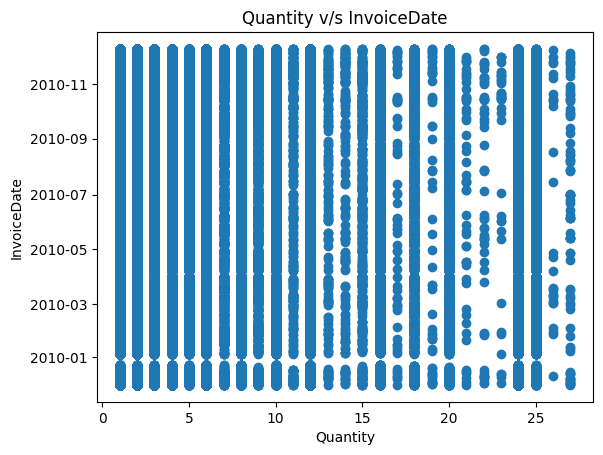

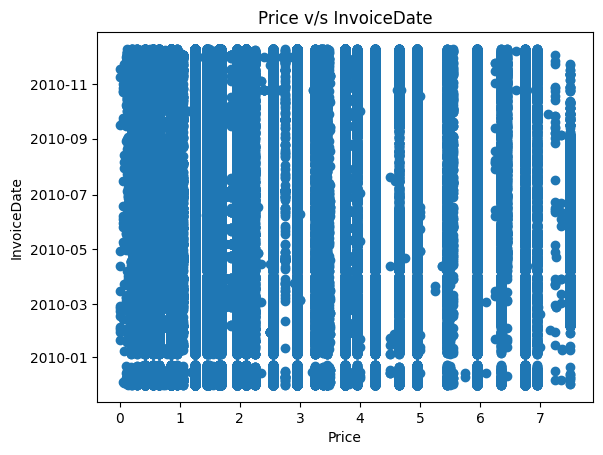

## Correlation:

## Missing Matrix:

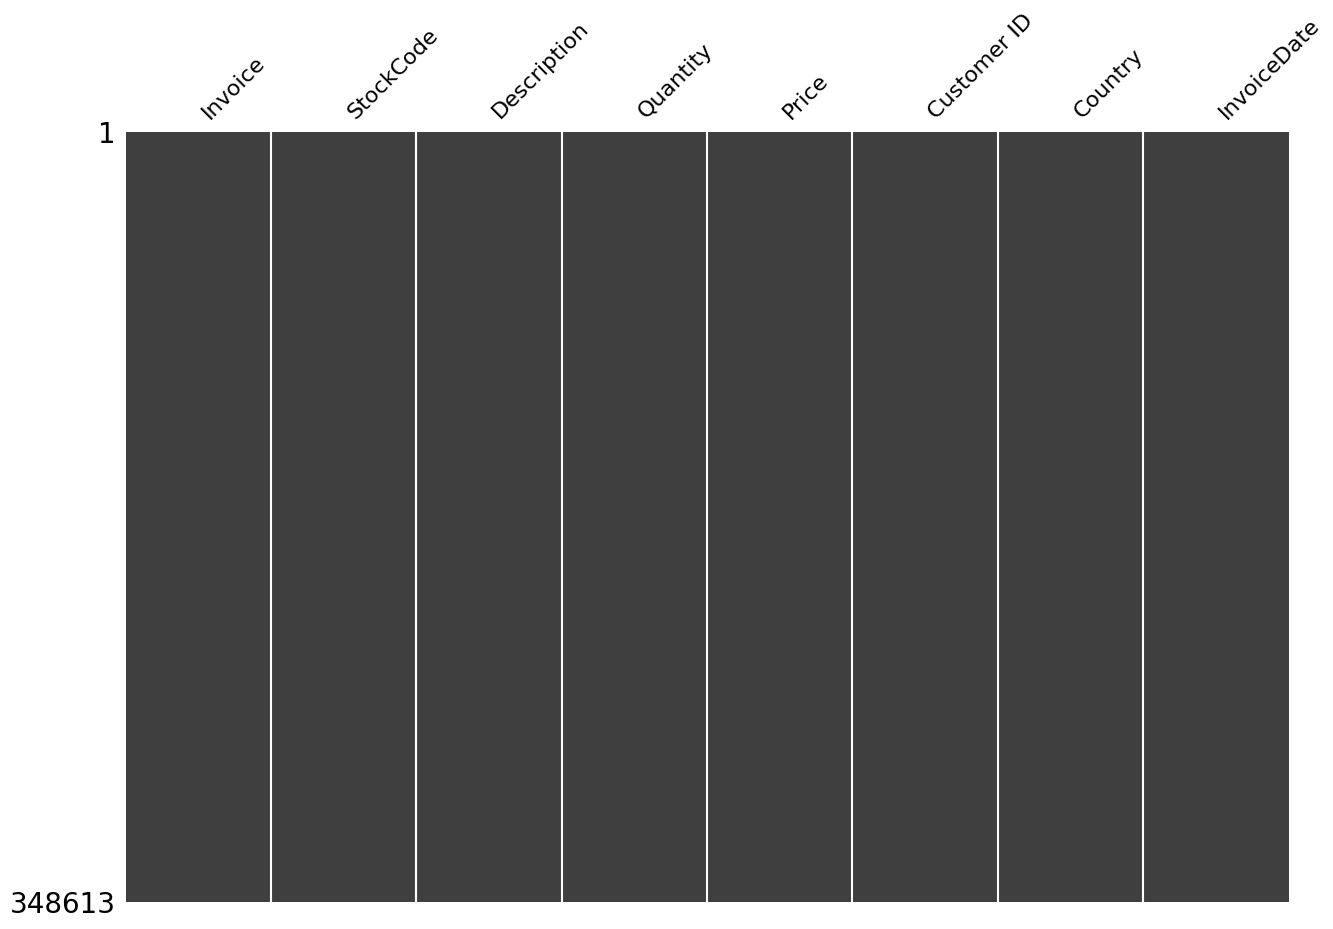

In [25]:
profile_df(df_clean)

Para el caso univariado, tenemos que la mayoria de los graficos se mantienen igual en cuanto a la forma de su distribución, y en algunos casos como el de Customer ID, el valor con mayor frecuencia cambia, esto se debe a la eliminación de datos que previamente podian estar relacionados con el Customer ID anterior. Y los cambios más notables son Quantity y Price, que eran más problematicos que las demás series, en cuanto a presencia de outliers y valores negativos, con esto se obtiene una visualización mucho más clara y que permite tener un análisis posterior más detallado.

Para el caso multivariado vemos que ahora se tiene una diferencia notable con respecto a la visualización previa sin limpieza, ya que ahora las correlaciones son mucho más notorias, siguen siendo negativas, pero alcanzan valores más negativos que antes. Y la visualización de los nulos nos permite observar que ya no existe la presencia de estos valores anomalos.

### 1.2.4 Obtención de TOPs [0.75 ptos]

Sin considerar los comentarios realizados en la sección 1.2 , *Don Mora* les pide obtener el **Top de 30 productos que generan más ganancias** para la tienda de retail. Deben considerar todo el registro temporal presente en el dataset y entregar la información en un gráfico de barras de los ingresos/cantidades v/s el nombre de los productos (Utilice `plotly`). ¿Los artículos más vendidos son los mismos que generan más ganancias?, Comente los resultados obtenidos.

**Resultados:**

In [26]:
def plot_top_productos(df, n=30):
    df = df.copy()
    df["Total"] = df["Quantity"] * df["Price"]
    agg = df.groupby("Description", as_index=False).agg(Ganancia=("Total", "sum"), Cantidad=("Quantity", "sum"))
    top = agg.sort_values("Ganancia", ascending=False).head(n)
    plot_df = top.melt(
        id_vars="Description", value_vars=["Ganancia", "Cantidad"], var_name="Metrica", value_name="Valor"
    )
    fig = px.bar(
        plot_df,
        x="Description",
        y="Valor",
        color="Metrica",
        barmode="group",
        title=f"Top {n} productos: Ganancia / Cantidad vs Producto",
    )
    fig.update_layout(xaxis_title="Producto", yaxis_title="Ganancia / Cantidad", xaxis_tickangle=-45)
    fig.show()

In [27]:
plot_top_productos(df_retail, 30)

Los productos con más ganacias no son los que se venden en mayor cantidad, esto se debe principalmente al precio por unidad de cada producto y la frecuencia en que es comprado. En este caso el 2do valor con más ganancia es el primero en cantidad, y el tercero en ganancia, se vende muy poco en cantidad. No hay tendencia.

### 1.2.5 Visualización del registro temporal [0,75 ptos]

El dueño del retail en su afán por saber más sobre los datos de su firma les solicita que grafiquen las ventas respecto al tiempo. Con esto les aclara que durante el día tienen muchas variaciones en sus ventas, por lo que les recomienda que consideren el registro temporal como `año-mes-día`. ¿Es posible observar datos extraños?, Comente lo que observa del gráfico.

In [28]:
def plot_ventas(dataframe):
    df = dataframe.copy()
    df["Total"] = df["Quantity"] * df["Price"]
    ventas_diarias = df.groupby(df["InvoiceDate"].dt.date)["Total"].sum().reset_index()
    ventas_diarias["InvoiceDate"] = pd.to_datetime(ventas_diarias["InvoiceDate"])
    fig = px.line(ventas_diarias, x="InvoiceDate", y="Total", title="Ventas Diarias")
    fig.update_layout(xaxis_title="Fecha", yaxis_title="Ventas Totales")
    fig.show()

In [29]:
plot_ventas(df_clean)

Se puede observar una caida abrupta entre el 16 de diciembre de 2009 y el 22 de diciembre de 2009, lo cual es una caida extraña considerando que es una fecha de festividades (navidad y fin de año), por lo que nos hace pensar que los datos no se procesaron correctamente para esas fechas, dejando ese comportamiento extraño como evidencia, ya que todo el gráfico en general es más bien suave considerando el contexto de las ventas.

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>